## Decision Tree Classifier

A decision tree is a flowchart-like tree structure where an internal node represents a feature, the branch represents a decision rule, and each leaf node represents the outcome.

You do not need to standardize or normalize data for decision tree models. Decision trees are scale-invariant, meaning they make decisions based on the order of values rather than their absolute magnitude.

Tutorial guide: https://www.datacamp.com/tutorial/decision-tree-classification-python

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import random

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

Read data

In [89]:
train_df = pd.read_csv('../../data/processed/supervised/train_data.csv')
val_df = pd.read_csv('../../data/processed/supervised/val_data.csv')
test_df = pd.read_csv('../../data/processed/supervised/test_data.csv')

In [90]:
X_train = train_df.drop('fraud', axis=1)
y_train = train_df['fraud']

X_val = val_df.drop('fraud', axis=1)
y_val = val_df['fraud']

X_test = test_df.drop('fraud', axis=1)
y_test = test_df['fraud']

Build decision tree model

In [ ]:
seen = set()
results = []

while len(results) < 15:
    params = {
    "max_depth": random.choice([3, 5, 8, 10, 15, None]),
    "min_samples_split": random.choice([2, 5, 10, 20, 30]),
    "min_samples_leaf": random.choice([1, 2, 5, 10, 15])
    }

    key = tuple(params.items())
    if key in seen:
        continue
    seen.add(key)

    clf = DecisionTreeClassifier(**params, random_state=RANDOM_SEED, class_weight={0: 1, 1: 10}, criterion="gini")
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    perc = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    results.append({
        "params": params,
        "accuracy": acc,
        "precision": perc,
        "recall": rec,
        "f1_score": f1}
        )

In [92]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["recall", "f1_score"], ascending=[False, False])

results_df

,params,accuracy,precision,recall,f1_score
2,"{'max_depth': 5, 'min_samples_split': 5, 'min_...",0.992064,0.584507,0.951042,0.724029
6,"{'max_depth': 5, 'min_samples_split': 30, 'min...",0.992064,0.584507,0.951042,0.724029
9,"{'max_depth': 5, 'min_samples_split': 20, 'min...",0.992064,0.584507,0.951042,0.724029
10,"{'max_depth': 8, 'min_samples_split': 2, 'min_...",0.994105,0.662271,0.941667,0.777634
12,"{'max_depth': 8, 'min_samples_split': 5, 'min_...",0.994105,0.662271,0.941667,0.777634
14,"{'max_depth': 10, 'min_samples_split': 2, 'min...",0.994299,0.672156,0.935417,0.782230
8,"{'max_depth': None, 'min_samples_split': 30, '...",0.994618,0.687117,0.933333,0.791519
13,"{'max_depth': 8, 'min_samples_split': 2, 'min_...",0.994082,0.663212,0.933333,0.775422
5,"{'max_depth': 3, 'min_samples_split': 2, 'min_...",0.993181,0.626928,0.931250,0.749371
7,"{'max_depth': 3, 'min_samples_split': 30, 'min...",0.993181,0.626928,0.931250,0.749371


In [ ]:
best_params = results_df.iloc[0]['params']

train_val_df = pd.concat([train_df, val_df], ignore_index=True)

X_train_val = train_val_df.drop('fraud', axis=1)
y_train_val = train_val_df['fraud']

clf_final = DecisionTreeClassifier(
    class_weight={0: 1, 1: 10},
    random_state=RANDOM_SEED,
    criterion="gini",
    max_depth=best_params["max_depth"],
    min_samples_leaf=best_params["min_samples_leaf"],
    min_samples_split=best_params["min_samples_split"]
)

clf_final.fit(X_train_val, y_train_val)
y_test_pred = clf_final.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

print("Final test accuracy:", accuracy)
print("Final test precision:", precision)
print("Final test recall:", recall)
print("Final test f1:", f1)

Final test accuracy: 0.9923675260682657
Final test precision: 0.5903225806451613
Final test recall: 0.953125
Final test f1: 0.7290836653386454


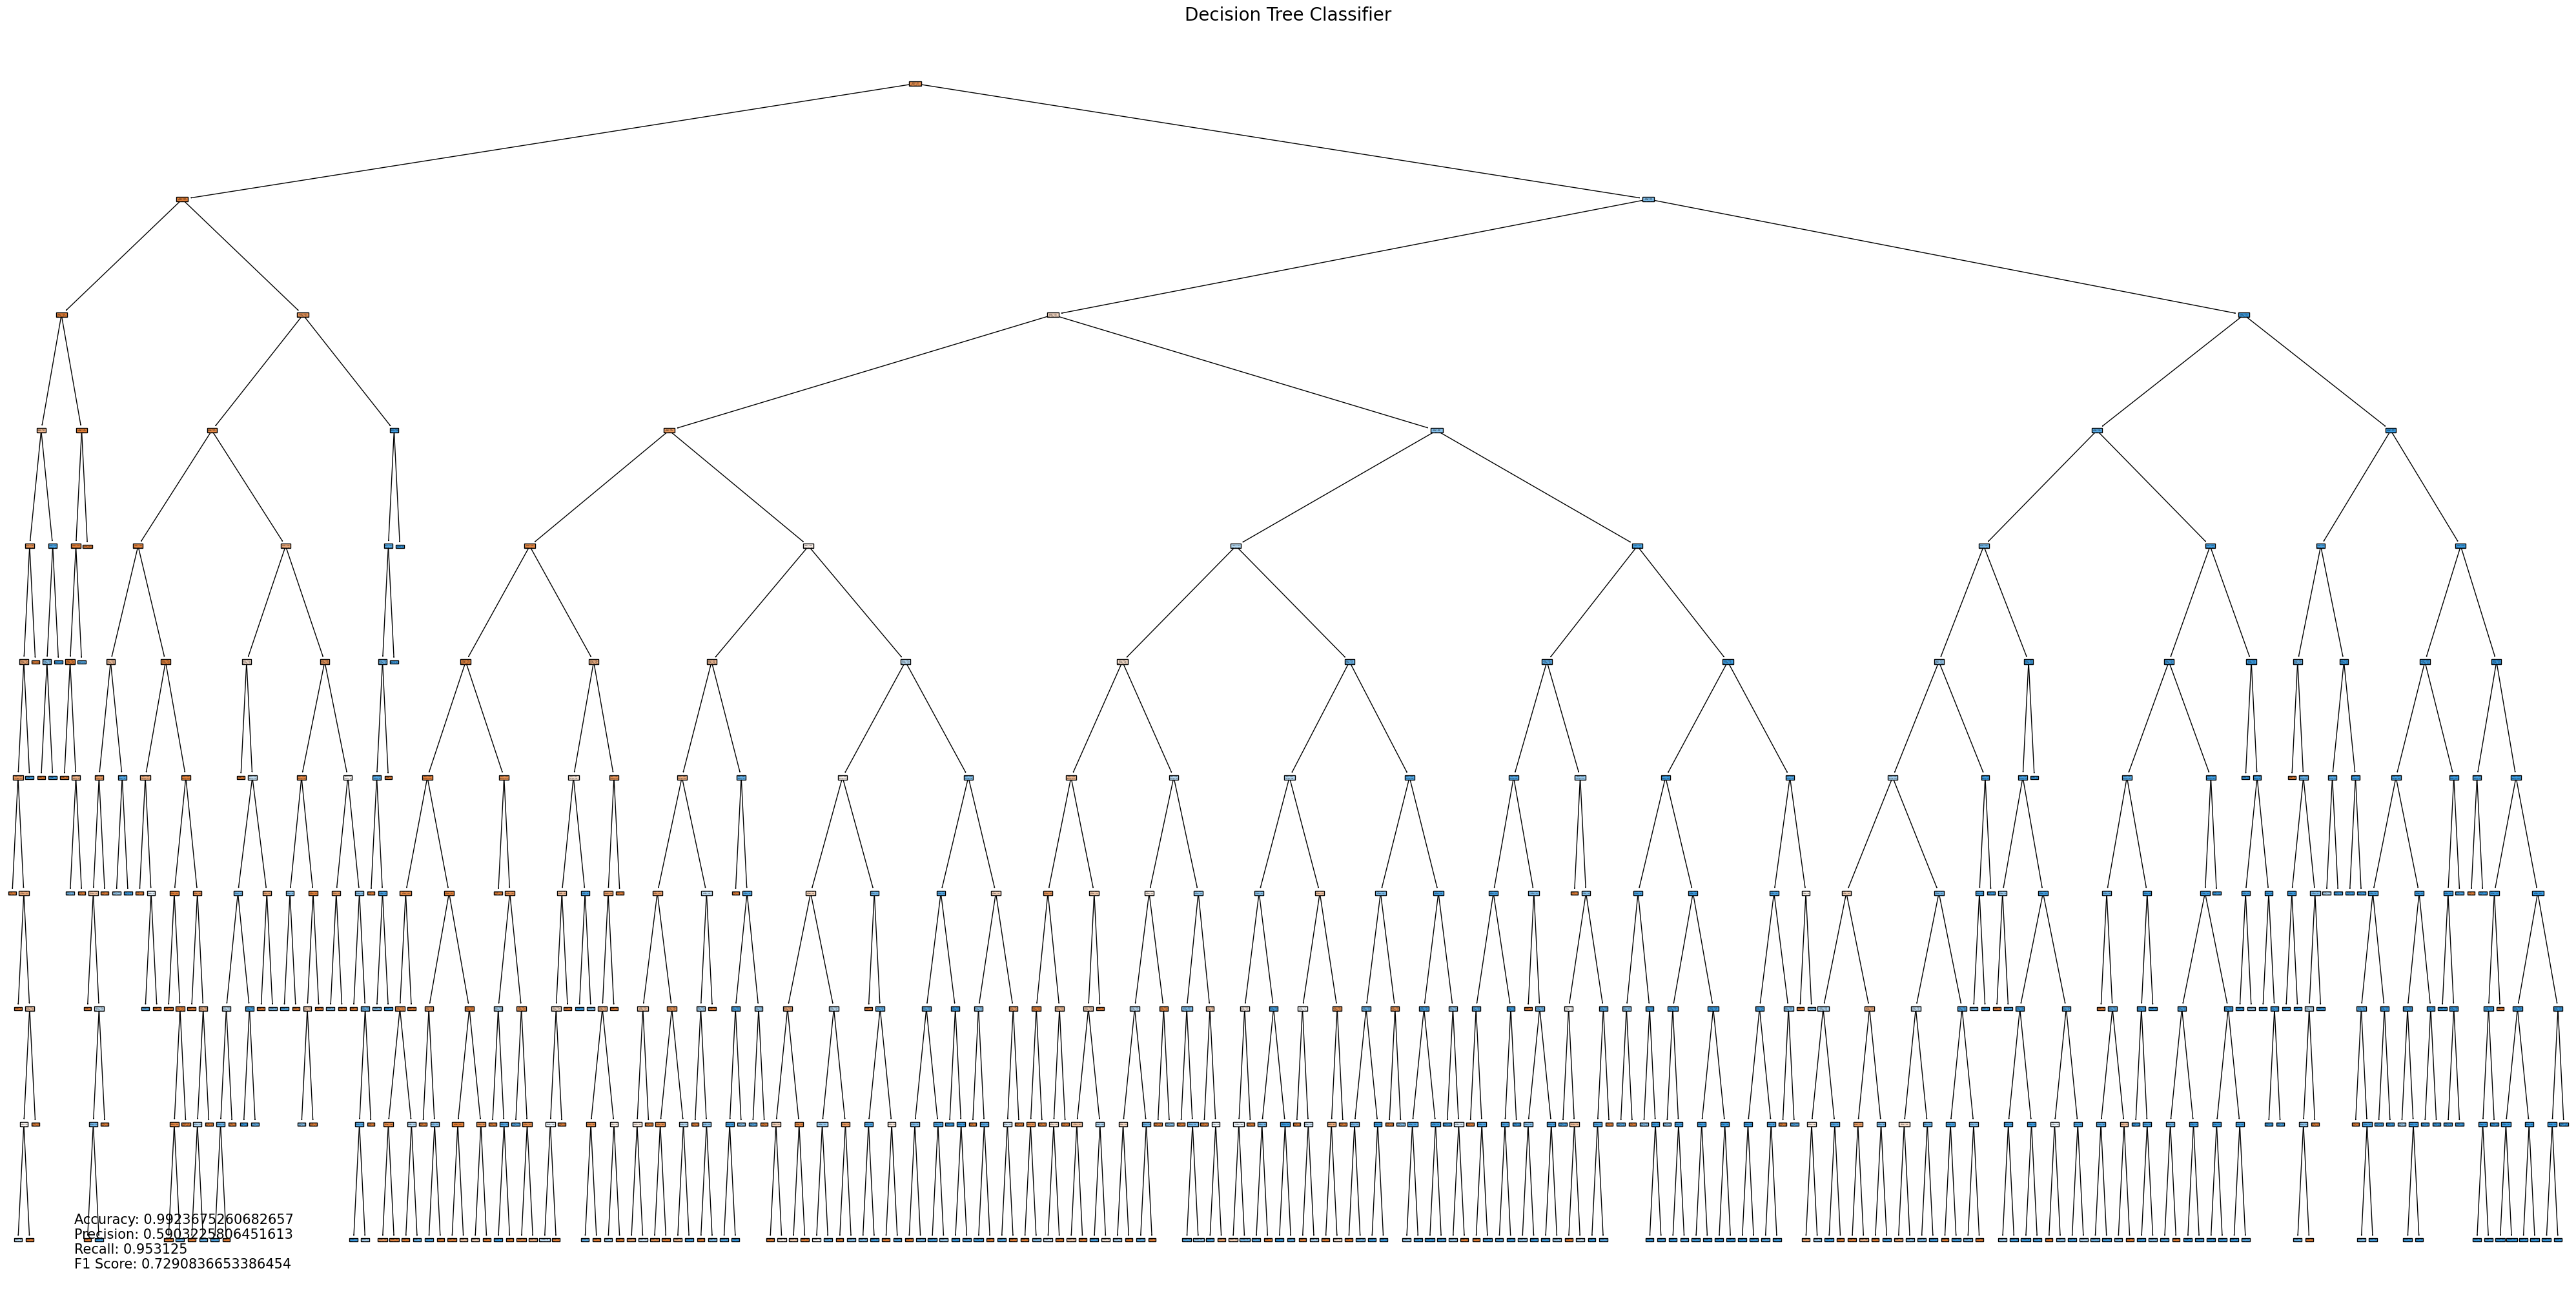

In [94]:
plt.figure(figsize=(40,20))
plot_tree(clf, filled=True)
plt.tight_layout()
plt.title('Decision Tree Classifier', fontsize=20)
plt.figtext(0.03, 0.03, f'Accuracy: {accuracy}\nPrecision: {precision}\nRecall: {recall}\nF1 Score: {f1}', ha='left', fontsize=15)
plt.savefig("../../results/DecisionTree.svg")
plt.show()

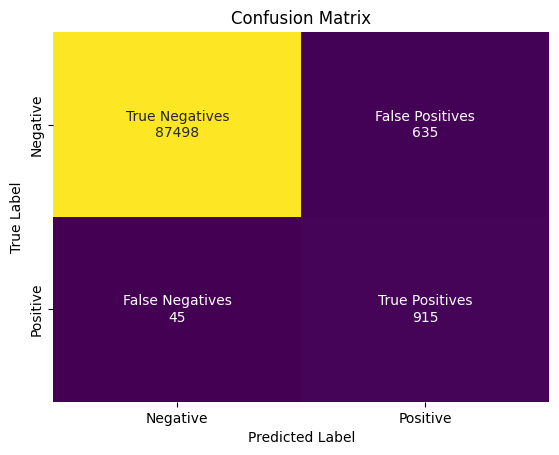

In [95]:
cf_matrix = confusion_matrix(y_test, y_test_pred)

group_names = ["True Negatives", "False Positives", "False Negatives", "True Positives"]

group_counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.array(labels).reshape(2,2)

matrix = sns.heatmap(cf_matrix, annot=labels, fmt='', cmap="viridis", cbar=False)
matrix.set_xlabel("Predicted Label")
matrix.set_ylabel("True Label")
matrix.set_xticklabels(["Negative", "Positive"])
matrix.set_yticklabels(["Negative", "Positive"])
plt.title('Confusion Matrix')
plt.savefig("../../results/DecisionTreeCM.svg")
plt.show()

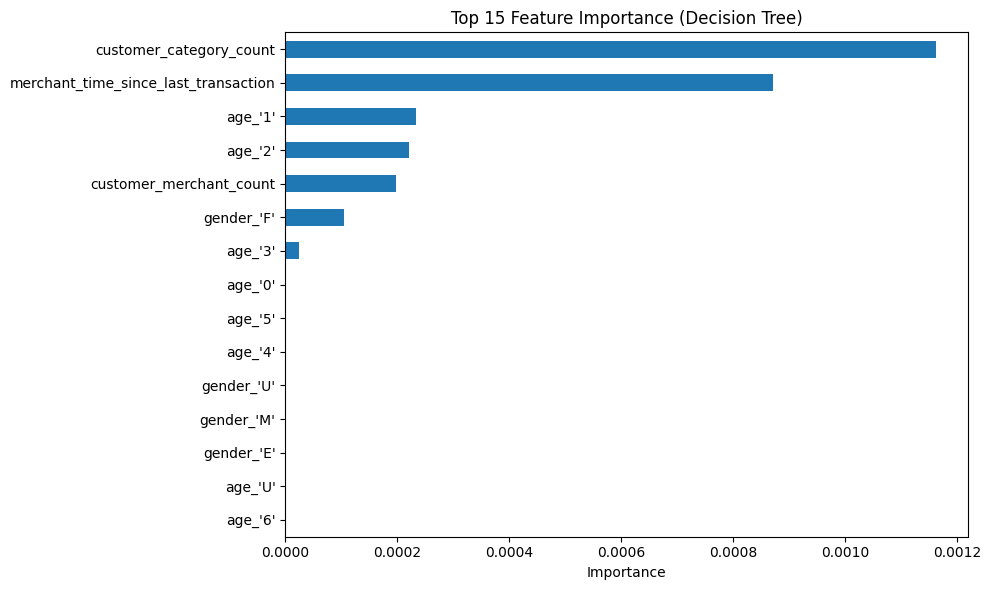

In [96]:
feat_imp = pd.Series(clf.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=True)[:15]

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh')
plt.title("Top 15 Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

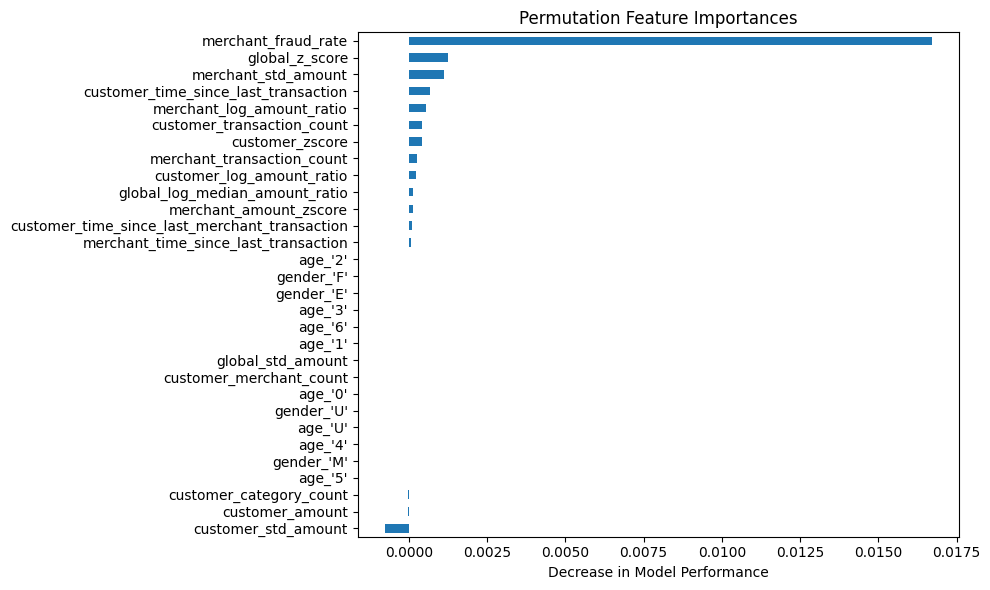

In [97]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    clf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

perm_imp = pd.Series(result.importances_mean, index=X_train.columns)
perm_imp = perm_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
perm_imp.sort_values().plot(kind='barh')
plt.title("Permutation Feature Importances")
plt.xlabel("Decrease in Model Performance")
plt.tight_layout()
plt.show()